In [22]:
import os

# Set your W&B token
os.environ["WANDB_API_KEY"]="???"

import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision.transforms as T
import numpy as np
import cv2
import graphviz
import pytorch_lightning as pl
import torchmetrics
import wandb
import timm
import albumentations as A
import pandas as pd
import ttach as tta
from tqdm import tqdm

from albumentations.pytorch import ToTensorV2
from torchview import draw_graph
from scipy.ndimage import gaussian_laplace
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor
from PIL import Image
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.metrics import f1_score


from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

%matplotlib inline

# Show full content in each cell
pd.set_option('display.max_colwidth', None)

# (Optional) Also expand columns and rows as needed
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', None)

In [3]:
DEVICE = "cuda"

# Agenda

1. [Augmentations](#Augmentations)
2. [Transfer Learning](#Transfer_Learning)
3. [GradCAM](#GradCAM)
4. [ResNet](#ResNet)
5. [EfficientNet](#EfficientNet)
6. [ConvNeXt](#ConvNeXt)
7. [Example with Cats and Dogs++](#Cats_and_Dogs)

# Resources
- [Chat with ChatGPT](https://chatgpt.com/share/68ecb782-82c0-8003-8202-b415c23e9195)
- [Cats and Dogs++ Kaggle Competition](https://www.kaggle.com/t/4ec748030ea944518199d2e7429ecb78)
- [torchvision.transforms](https://docs.pytorch.org/vision/stable/transforms.html)
- [Albumentations](https://albumentations.ai/)
- [Monai Transforms](https://docs.monai.io/en/stable/transforms.html)
- [torchvision.models](https://docs.pytorch.org/vision/main/models.html)
- [timm](https://github.com/huggingface/pytorch-image-models)
- [Grad-CAM](https://arxiv.org/abs/1610.02391)
- [pytorch-grad-cam](https://github.com/jacobgil/pytorch-grad-cam)
- [Captum](https://captum.ai/)
- [ResNet](https://arxiv.org/abs/1512.03385)
- [EfficientNet](https://arxiv.org/abs/1905.11946)
- [ConvNeXt](https://arxiv.org/abs/2201.03545)

# From Previous Lecture

In [4]:
# Define CIFAR-10 class names
CLASSES = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

class AlexNet(nn.Module):
    def __init__(self, num_classes, use_batchnorm=False):
        super(AlexNet, self).__init__()
        self.use_batchnorm = use_batchnorm

        # --- Convolutional layers ---
        self.conv1 = nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0)
        self.bn1 = nn.BatchNorm2d(96) if use_batchnorm else nn.Identity()
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2)

        self.conv2 = nn.Conv2d(96, 256, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(256) if use_batchnorm else nn.Identity()
        self.pool2 = nn.MaxPool2d(kernel_size=3, stride=2)

        self.conv3 = nn.Conv2d(256, 384, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(384) if use_batchnorm else nn.Identity()

        self.conv4 = nn.Conv2d(384, 384, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(384) if use_batchnorm else nn.Identity()

        self.conv5 = nn.Conv2d(384, 256, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(256) if use_batchnorm else nn.Identity()
        self.pool5 = nn.MaxPool2d(kernel_size=3, stride=2)

        # --- Activation and Dropout ---
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(p=0.6)

        # --- Fully connected layers ---
        self.fc1 = nn.Linear(256 * 6 * 6, 4096)
        self.fc2 = nn.Linear(4096, 4096)
        self.fc3 = nn.Linear(4096, num_classes)

    def forward(self, x):
        # Convolutional feature extraction
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.pool5(self.relu(self.bn5(self.conv5(x))))

        # Flatten features
        x = torch.flatten(x, 1)

        # Fully connected classification head
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        x = self.fc3(x)

        return x

In [5]:
class LitCNN(pl.LightningModule):
    def __init__(
        self, 
        model_class,
        model_kwargs,
        initial_lr=1e-3, 
        final_lr=1e-5, 
        T_max=10,
    ):
        super().__init__()
        self.save_hyperparameters()
        self.model = model_class(**model_kwargs)
        self.criterion = nn.CrossEntropyLoss()
        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=len(CLASSES))
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=len(CLASSES))

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = logits.argmax(dim=-1)
        self.train_acc.update(preds, y)
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        acc = self.train_acc.compute()
        self.log("train_acc", acc, prog_bar=True)
        self.train_acc.reset()

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = logits.argmax(dim=-1)
        self.val_acc.update(preds, y)
        self.log("val_loss", loss, on_epoch=True, prog_bar=True)

    def on_validation_epoch_end(self):
        acc = self.val_acc.compute()
        self.log("val_acc", acc, prog_bar=True)
        self.val_acc.reset()

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            self.parameters(), 
            lr=self.hparams.initial_lr
        )
        scheduler = {
            "scheduler": torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, 
                T_max=self.hparams.T_max,
                eta_min=self.hparams.final_lr
            ),
            "interval": "step"
        }
        return (
            [optimizer],
            [scheduler]
        )

class CIFAR10DataModule(pl.LightningDataModule):
    def __init__(self, data_root="../../data", batch_size=64, num_workers=None):
        super().__init__()
        self.data_root = data_root
        self.batch_size = batch_size
        self.num_workers = num_workers or max(os.cpu_count()-1, 1)

    def setup(self, stage=None):
        # Load CIFAR-10 dataset
        transform = torchvision.transforms.Compose([
            torchvision.transforms.Resize(227),  # Resize for AlexNet
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
        self.train_ds = torchvision.datasets.CIFAR10(root=self.data_root, train=True, download=True, transform=transform)
        self.val_ds   = torchvision.datasets.CIFAR10(root=self.data_root, train=False, download=True, transform=transform)

    def train_dataloader(self):
        return torch.utils.data.DataLoader(
            self.train_ds, batch_size=self.batch_size, 
            shuffle=True, pin_memory=torch.cuda.is_available(),
            num_workers=self.num_workers
        )

    def val_dataloader(self):
        return torch.utils.data.DataLoader(
            self.val_ds, batch_size=self.batch_size, 
            shuffle=False, pin_memory=torch.cuda.is_available(),
            num_workers=self.num_workers
        )

<a id='Augmentations'></a>
# Augmentations

## 🎯 Goal  
Augmentations increase dataset diversity by applying **label-preserving transformations** to training data. Some augmentations may still change the label, but they follow the logic.  
They help models **generalize** better, **reduce overfitting**, and **simulate domain variability** (lighting, viewpoint, noise, etc.).

---

## Why Augmentation Matters

| Challenge | Augmentation Strategy | Benefit |
|------------|----------------------|----------|
| Small dataset | Random crops, flips, rotations | Expands sample variety |
| Domain shift | Color jitter, style transfer | Simulates new domains |
| Overfitting | Random erasing, mixup | Adds stochastic noise |
| Imbalanced data | Targeted augmentation for minority classes | Balances training distribution |

Mathematically, we want to enrich the empirical distribution $P_{train}(x, y)$  
so it better approximates $P_{real}(x, y)$:

$$
P_{aug}(x, y) = \sum_{k=1}^{K} T_k(P_{train}(x, y))
$$

where $T_k$ are augmentation transforms.

---

## Types of Augmentations

### 🖼️ Spatial (Geometric)
Transform image geometry:
- `Flip`, `Rotate`, `Translate`, `Zoom`, `Shear`, `Crop`
- Preserve pixel values but change pixel arrangement

$$
T_{geom}(x) = A \cdot x + b
$$
where $A$ is an affine transformation matrix.

---

### 🎨 Color / Intensity
Modify image color or brightness:
- `Brightness`, `Contrast`, `Saturation`, `Hue`, `Gamma`
- Used to simulate lighting and camera differences

$$
x' = \alpha x + \beta
$$

---

### 🔊 Noise and Blur
Add randomness to improve robustness:
- `GaussianNoise`, `MotionBlur`, `GaussianBlur`, `JPEGCompression`

---

### 🧩 Cutout / Erasing
Randomly remove parts of an image:
```python
RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3))
```

### 🧬 Mix-based Augmentations

Mix-based augmentations combine multiple samples to regularize the model and improve robustness.  
They are widely used in both **vision** and **audio** tasks.

---

#### 🔹 MixUp
Creates linear interpolations between two samples:

$$
\tilde{x} = \lambda x_i + (1 - \lambda)x_j, \quad
\tilde{y} = \lambda y_i + (1 - \lambda)y_j
$$

where $\lambda \sim \text{Beta}(\alpha, \alpha)$.

This encourages the model to behave linearly between examples, improving smoothness of decision boundaries and reducing overconfidence.

---

#### 🔹 CutMix
Replaces a random patch of one image with the same region from another:

$$
\tilde{x} = M \odot x_i + (1 - M) \odot x_j, \quad
\tilde{y} = \lambda y_i + (1 - \lambda)y_j
$$

where $M$ is a binary mask defining the cut region and $\lambda$ corresponds to the ratio of the unmasked area.  
CutMix combines the localization benefit of Cutout and the regularization of MixUp.

---

## 🧰 Libraries for Augmentations

Several open-source libraries provide efficient and flexible augmentation pipelines for deep learning.  
They differ by supported domains, API style, and performance.

---

### 🔸 [torchvision.transforms](https://pytorch.org/vision/stable/transforms.html)
- Official PyTorch library for basic image augmentations.
- Provides simple, composable transforms such as `RandomCrop`, `ColorJitter`, `RandomAffine`, and others.
- Integrates seamlessly with PyTorch `Dataset` and `DataLoader`.

**Example:**
```python
from torchvision import transforms

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
```

### 🔸 [Albumentations](https://albumentations.ai)

- A fast, flexible, and production-grade augmentation library widely used in both research and industry.  
- Key Features
  - Rich set of geometric, color, and pixel-level transformations.  
  - Advanced augmentations such as `Cutout`, `GridDistortion`, `ElasticTransform`, `RandomFog`, and `CLAHE`.  
  - Based on **NumPy** and **OpenCV**, optimized for high performance.  
  - Compatible with **PyTorch**, **TensorFlow**, and **ONNX** workflows.  

**Example:**
```python
import albumentations as A

transform = A.Compose([
    A.RandomCrop(224, 224),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Cutout(num_holes=8, max_h_size=16, max_w_size=16, p=0.5),
])
```

### 🔸 [MONAI Transforms](https://docs.monai.io/en/stable/transforms.html)

- Description: A specialized augmentation and preprocessing library built on top of PyTorch, designed for medical imaging tasks such as CT, MRI, PET, and ultrasound analysis.  
- Key Features:
  - Supports **2D**, **3D**, and **multimodal** image data.  
  - Domain-specific transforms for intensity normalization, resampling, orientation, spacing, and elastic deformations.  
  - Composable, dictionary-based API (`keys=["image", "label"]`) — perfectly suited for paired data (image + mask).  
  - Integrates seamlessly with **MONAI pipelines**, **PyTorch Lightning**, and **NVIDIA Clara** ecosystem.

**Example:**
```python
from monai.transforms import (
    Compose, RandFlipd, RandRotated, RandZoomd, RandGaussianNoised
)

train_transforms = Compose([
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandRotated(keys=["image", "label"], range_x=15, prob=0.3),
    RandZoomd(keys=["image", "label"], min_zoom=0.9, max_zoom=1.1, prob=0.3),
    RandGaussianNoised(keys=["image"], prob=0.2)
])
```

/tmp/ipykernel_3126616/1678779907.py:26: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  "Elastic Transform": A.ElasticTransform(


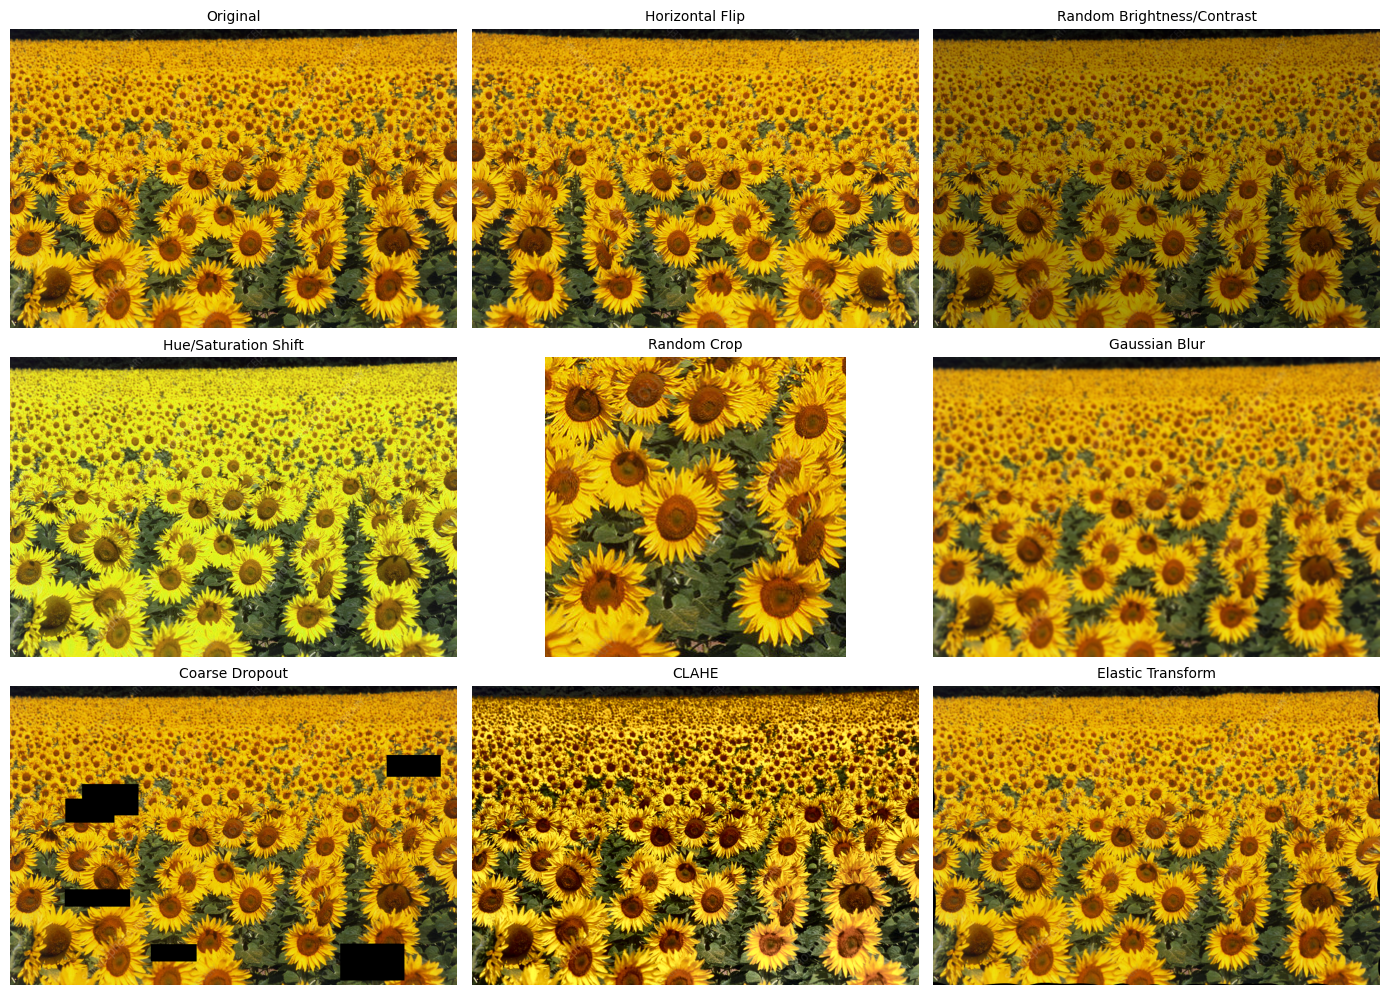

In [6]:
# --- Load Image ---
image_path = "images/sunplowers.jpeg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# --- Define Augmentations ---
augmentations = {
    "Original": A.NoOp(),
    "Horizontal Flip": A.HorizontalFlip(p=1),
    "Random Brightness/Contrast": A.RandomBrightnessContrast(p=1, brightness_limit=0.3, contrast_limit=0.3),
    "Hue/Saturation Shift": A.HueSaturationValue(p=1, hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20),
    "Random Crop": A.RandomCrop(height=300, width=300, p=1),
    "Gaussian Blur": A.GaussianBlur(blur_limit=(7, 15), p=1),
    "Coarse Dropout": A.CoarseDropout(
        num_holes_range=(4, 8),
        hole_height_range=(0.05, 0.15),
        hole_width_range=(0.05, 0.15),
        fill=0,
        p=1,
    ),
    "CLAHE": A.CLAHE(
            clip_limit=6.0,          
            tile_grid_size=(4, 4),   
            p=1
        ),
    "Elastic Transform": A.ElasticTransform(
        alpha=250,               
        sigma=15,                
        alpha_affine=70,         
        p=1
    ),
}

# --- Apply and Visualize ---
n_cols = 3
n_rows = (len(augmentations) + n_cols - 1) // n_cols
plt.figure(figsize=(14, 10))

for i, (name, aug) in enumerate(augmentations.items()):
    augmented = aug(image=image)["image"]
    plt.subplot(n_rows, n_cols, i + 1)
    plt.imshow(augmented)
    plt.title(name, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
class CIFAR10AlbumentationsDataset(torchvision.datasets.CIFAR10):
    """Wrapper to apply Albumentations transforms."""
    def __getitem__(self, idx):
        image, label = self.data[idx], self.targets[idx]
        image = image.transpose((1, 2, 0)) if image.ndim == 3 and image.shape[0] == 3 else image
        if self.transform:
            image = self.transform(image=image)["image"]
        return image, label

class CIFAR10DataModuleAugmentations(CIFAR10DataModule):

    def setup(self, stage=None):
        train_tfms = A.Compose([
            A.Resize(227, 227),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.5, contrast_limit=0.5, p=0.5),
            A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5),
            A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
            ToTensorV2()
        ])

        val_tfms = A.Compose([
            A.Resize(227, 227),
            A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
            ToTensorV2()
        ])
        
        self.train_ds = CIFAR10AlbumentationsDataset(
            root=self.data_root, train=True, download=True, transform=train_tfms
        )
        self.val_ds = CIFAR10AlbumentationsDataset(
            root=self.data_root, train=False, download=True, transform=val_tfms
        )


In [7]:
N_EPOCHS = 10

datamodule = CIFAR10DataModuleAugmentations(num_workers=12, batch_size=64)
datamodule.setup()
lit_model = LitCNN(
    model_class=AlexNet,
    model_kwargs={
        "use_batchnorm": False,
        "num_classes": len(CLASSES)
    },
    initial_lr=1e-3,
    final_lr=1e-5,
    T_max=N_EPOCHS * len(datamodule.train_dataloader()),
)
wandb_logger = WandbLogger(
    project="kse_deep_learning_course", 
    name="cifar10_alexnet_withBN_augmentations"
)
checkpoint_cb = ModelCheckpoint(
    monitor="val_acc", mode="max",
    save_top_k=1, filename="cifar10_alexnet_withBN_augmentations-{epoch:02d}-{val_acc:.4f}"
)
lr_monitor = LearningRateMonitor(logging_interval="step")
trainer = pl.Trainer(
    max_epochs=N_EPOCHS,
    logger=wandb_logger,
    callbacks=[checkpoint_cb, lr_monitor],
    accelerator="auto",
    devices=1 if DEVICE == "cuda" else None,
    precision="16-mixed"
)

trainer.fit(lit_model, datamodule=datamodule)
wandb.finish()

/gpfs/helios/home/volodymyr1/src/kse_deep_learning/.venv/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /gpfs/helios/home/volodymyr1/src/kse_deep_learning/. ...
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
wandb: Currently logged in as: sydorskyiv (sydorskyiv-igor-sikorsky-kyiv-polytechnic-institute) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/gpfs/helios/home/volodymyr1/src/kse_deep_learning/.venv/lib/python3.11/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | model     | AlexNet            | 58.3 M | train
1 | criterion | CrossEntropyLoss   | 0      | train
2 | train_acc | MulticlassAccuracy | 0      | train
3 | val_acc   | MulticlassAccuracy | 0      | train
---------------------------------------------------------
58.3 M    Trainable params
0         Non-trainable params
58.3 M    Total params
233.289   Total estimated model params size (MB)
22        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_epochs=10` reached.


epoch,▁▁▁▁▁▁▁▁▁▁▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▇▇███
lr-Adam,███████▇▇▇▇▇▇▆▆▅▅▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁
train_acc,▁▃▄▅▆▆▇▇██
train_loss_epoch,█▆▅▄▄▃▂▂▁▁
train_loss_step,█▇▆▆▄▄▄▃▅▅▄▃▄▅▄▃▃▃▃▃▂▂▄▃▃▅▃▁▃▁▂▁▂▁▁▁▁▁▂▂
trainer/global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇█
val_acc,▁▂▄▅▅▆▇███
val_loss,█▆▅▄▄▃▂▁▁▁
epoch,9
lr-Adam,1e-05
train_acc,0.50948


In [8]:
N_EPOCHS = 20

datamodule = CIFAR10DataModuleAugmentations(num_workers=12, batch_size=64)
datamodule.setup()
lit_model = LitCNN(
    model_class=AlexNet,
    model_kwargs={
        "use_batchnorm": True,
        "num_classes": len(CLASSES)
    },
    initial_lr=1e-3,
    final_lr=1e-5,
    T_max=N_EPOCHS * len(datamodule.train_dataloader()),
)
wandb_logger = WandbLogger(
    project="kse_deep_learning_course", 
    name="cifar10_alexnet_withBN_augmentations_20epochs"
)
checkpoint_cb = ModelCheckpoint(
    monitor="val_acc", mode="max",
    save_top_k=1, filename="cifar10_alexnet_withBN_augmentations_20epochs-{epoch:02d}-{val_acc:.4f}"
)
lr_monitor = LearningRateMonitor(logging_interval="step")
trainer = pl.Trainer(
    max_epochs=N_EPOCHS,
    logger=wandb_logger,
    callbacks=[checkpoint_cb, lr_monitor],
    accelerator="auto",
    devices=1 if DEVICE == "cuda" else None,
    precision="16-mixed"
)

trainer.fit(lit_model, datamodule=datamodule)
wandb.finish()

/gpfs/helios/home/volodymyr1/src/kse_deep_learning/.venv/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /gpfs/helios/home/volodymyr1/src/kse_deep_learning/. ...
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/gpfs/helios/home/volodymyr1/src/kse_deep_learning/.venv/lib/python3.11/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | model     | AlexNet            | 58.3 M | train
1 | criterion | CrossEntropyLoss   | 0      | train
2 | train_acc | MulticlassAccuracy | 0      | train
3 | val_acc   | MulticlassAccuracy | 0      | train
---------------------------------------------------------
58.3 M    Trainable params
0         Non-trainable params
58.3 M    Total params
233.300   Total estimated model params size (MB)
22        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_epochs=20` reached.


epoch,▁▁▁▂▂▂▂▂▂▂▂▃▃▃▄▄▄▅▅▅▅▅▅▅▅▆▇▇▇▇▇▇▇███████
lr-Adam,████████▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▅▄▄▄▃▃▃▃▃▃▃▂▂▁▁▁▁
train_acc,▁▁▂▃▄▅▆▆▆▇▇▇▇▇██████
train_loss_epoch,█▆▆▅▅▄▃▃▃▂▂▂▂▁▁▁▁▁▁▁
train_loss_step,█▇██▇▇▇▇▇▇▅▄▅▅▄▄▂▃▃▄▃▄▃▃▁▁▂▃▁▂▁▂▃▃▃▃▁▂▃▁
trainer/global_step,▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇█████
val_acc,▁▁▂▄▅▆▆▇▇▇▇█████████
val_loss,██▇▅▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁
epoch,19
lr-Adam,1e-05
train_acc,0.73384


## Test-Time Augmentations (TTA)

**Test-Time Augmentation (TTA)** is a technique used **during inference** to improve model robustness and performance without retraining.  
Instead of evaluating each test image once, we apply **several deterministic augmentations**, run predictions for all of them, and then **aggregate** the outputs (usually by averaging or voting).


![](images/tta_aug.jpg) <be>
    
*Taken from [Train and Test-time Data Augmentation](https://blog.dailydoseofds.com/p/train-and-test-time-data-augmentation)*

---

### Idea

Given an input image $x$, apply a set of transformations $\{T_1, T_2, ..., T_n\}$:

$$
\hat{y} = \frac{1}{n} \sum_{i=1}^{n} f(T_i(x))
$$

where:
- $f$ — trained model  
- $T_i(x)$ — augmented version of $x$  
- $\hat{y}$ — final averaged prediction  

This helps reduce overfitting to specific image orientations, crops, or lighting conditions, improving **generalization**.

---

### Common TTA Techniques

| Category | Examples | Description |
|-----------|-----------|-------------|
| **Geometric** | Horizontal / Vertical Flip, Rotation (90°), Resize | Simulates viewpoint or orientation changes |
| **Photometric** | Brightness / Contrast Jitter, CLAHE, Gamma Correction | Invariance to lighting or color differences |
| **Spatial Crops** | Center Crop, Five Crop (corners + center), Ten Crop (flipped variants) | Robustness to partial occlusion and framing |
| **Scale Ensemble** | Evaluate on multiple resolutions (e.g., 224, 256, 288) | Captures multi-scale features |

---

### Aggregation Strategies

| Method | Description |
|---------|--------------|
| **Mean (Soft Voting)** | Average probabilities from all augmentations → robust and smooth |
| **Max / Median** | Keeps strongest signals but less stable |
| **Majority Vote (Hard Voting)** | Useful for discrete class outputs |


In [12]:
best_model = LitCNN.load_from_checkpoint(
    "kse_deep_learning_course/o3drrhqv/checkpoints/cifar10_alexnet_withBN_augmentations_20epochs-epoch=19-val_acc=0.7617.ckpt",
    model_class=AlexNet,
    model_kwargs={
        "use_batchnorm": True,
        "num_classes": len(CLASSES)
    },
)
best_model.to(DEVICE)
best_model.eval()

transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize(227),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
testset = torchvision.datasets.CIFAR10(root="../../data", train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=8)

all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in tqdm(testloader):
        imgs = imgs.to(DEVICE)
        logits = best_model(imgs)
        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.numpy())

y_true = np.concatenate(all_labels)
y_pred = np.concatenate(all_preds)

f1_no_tta = f1_score(y_true, y_pred, average="macro")
print(f"🎯 Macro F1 (No TTA): {f1_no_tta:.4f}")

tta_transforms = tta.aliases.flip_transform()  # H/V flips
tta_model = tta.ClassificationTTAWrapper(best_model, tta_transforms)

all_preds_tta = []

with torch.no_grad():
    for imgs, labels in tqdm(testloader):
        imgs = imgs.to(DEVICE)
        logits = tta_model(imgs)
        preds = torch.argmax(logits, dim=1)
        all_preds_tta.append(preds.cpu().numpy())

y_pred_tta = np.concatenate(all_preds_tta)

f1_tta = f1_score(y_true, y_pred_tta, average="macro")
print(f"🧩 Macro F1 (With TTA): {f1_tta:.4f}")

improvement = (f1_tta - f1_no_tta) * 100
print(f"✅ F1 Improvement with TTA: {improvement:+.2f}%")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:04<00:00, 33.99it/s]


🎯 Macro F1 (No TTA): 0.7608


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:07<00:00, 20.01it/s]

🧩 Macro F1 (With TTA): 0.7757
✅ F1 Improvement with TTA: +1.49%


<a id='Transfer_Learning'></a>
# Transfer Learning

## 🎯 Goal  
Transfer Learning leverages **knowledge learned from large datasets or related tasks** to improve model performance and training efficiency on a new (often smaller) target dataset.

Instead of training a neural network **from scratch**, we **reuse a pretrained model** — usually trained on a large benchmark like **ImageNet** — and fine-tune it for a specific downstream task.

---

## Motivation

| Challenge | How Transfer Learning Helps |
|------------|-----------------------------|
| Limited data | Reuses generalized feature extractors learned from large datasets |
| High training cost | Saves compute time — most layers are pretrained |
| Slow convergence | Starts from meaningful weights, not random initialization |
| Poor generalization | Leverages diverse representations learned from millions of images |

Deep CNNs like **ResNet**, **EfficientNet**, or **ConvNeXt** learn hierarchical feature maps that are highly transferable:
- **Early layers** → detect general patterns (edges, corners, colors)  
- **Middle layers** → encode shapes and textures  
- **Later layers** → specialize in task-specific semantics  

Thus, we can **freeze** early layers and **fine-tune** deeper ones.

---

## 2 Types of Transfer Learning

| Type | Description | Example |
|------|--------------|----------|
| **Feature Extraction** | Use pretrained network as a **fixed feature extractor**; only train new classifier head. | `for param in model.features.parameters(): param.requires_grad = False` |
| **Fine-tuning** | Initialize with pretrained weights, but allow **all layers to update** slightly. | Often used for medium-sized datasets (e.g., CIFAR-10, medical images). |
| **Domain Adaptation** | Adapt model from one domain (e.g., natural images) to another (e.g., X-ray, MRI). | Use few labeled samples + self-supervised adaptation. |
| **Self-supervised Transfer** | Pretrain using contrastive/self-supervised objectives instead of labels. | SimCLR, MoCo, BYOL. |

---

## Implementation Example

### [torchvision.models](https://docs.pytorch.org/vision/main/models.html)

Here’s how to fine-tune an **ImageNet-pretrained ResNet18** for a 10-class dataset (e.g., CIFAR-10):

```python
import torch
import torch.nn as nn
import torchvision.models as models

NUM_CLASSES = 10

# Load pretrained model
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Replace classifier head
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, NUM_CLASSES)
```

### [timm](https://github.com/huggingface/pytorch-image-models)

[`timm`](https://github.com/huggingface/pytorch-image-models) is an advanced model zoo providing hundreds of pretrained architectures — including **EfficientNet**, **ConvNeXt**, **RegNet**, **Vision Transformers (ViT)**, and more.  
It’s designed for flexible transfer learning, with a unified API and built-in pretrained weights.

Below is an example of fine-tuning **EfficientNet-B0** on a 10-class dataset (e.g., CIFAR-10):

```python
import timm
import torch
import torch.nn as nn

NUM_CLASSES = 10

# Load pretrained EfficientNet-B0
model = timm.create_model("efficientnet_b0", pretrained=True)

# Replace classifier head
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, NUM_CLASSES)

# Example forward pass
x = torch.randn(8, 3, 224, 224)
out = model(x)
print(out.shape)  # torch.Size([8, 10])
```

In [9]:
class CIFAR10DataModuleAugmentationsResNet18(CIFAR10DataModule):

    def setup(self, stage=None):
        train_tfms = A.Compose([
            A.Resize(224, 224),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.5, contrast_limit=0.5, p=0.5),
            A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5),
            A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
            ToTensorV2()
        ])

        val_tfms = A.Compose([
            A.Resize(224, 224),
            A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
            ToTensorV2()
        ])
        
        self.train_ds = CIFAR10AlbumentationsDataset(
            root=self.data_root, train=True, download=True, transform=train_tfms
        )
        self.val_ds = CIFAR10AlbumentationsDataset(
            root=self.data_root, train=False, download=True, transform=val_tfms
        )

In [10]:
N_EPOCHS = 20

datamodule = CIFAR10DataModuleAugmentationsResNet18(num_workers=12, batch_size=64)
datamodule.setup()
lit_model = LitCNN(
    model_class=timm.create_model,
    model_kwargs={
        "model_name": "resnet18.a1_in1k",
        "num_classes": len(CLASSES),
        "pretrained": False
    },
    initial_lr=1e-3,
    final_lr=1e-5,
    T_max=N_EPOCHS * len(datamodule.train_dataloader()),
)
wandb_logger = WandbLogger(
    project="kse_deep_learning_course", 
    name="cifar10_resnet18_baseline"
)
checkpoint_cb = ModelCheckpoint(
    monitor="val_acc", mode="max",
    save_top_k=1, filename="cifar10_resnet18_baseline-{epoch:02d}-{val_acc:.4f}"
)
lr_monitor = LearningRateMonitor(logging_interval="step")
trainer = pl.Trainer(
    max_epochs=N_EPOCHS,
    logger=wandb_logger,
    callbacks=[checkpoint_cb, lr_monitor],
    accelerator="auto",
    devices=1 if DEVICE == "cuda" else None,
    precision="16-mixed"
)

trainer.fit(lit_model, datamodule=datamodule)
wandb.finish()

/gpfs/helios/home/volodymyr1/src/kse_deep_learning/.venv/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /gpfs/helios/home/volodymyr1/src/kse_deep_learning/. ...
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/gpfs/helios/home/volodymyr1/src/kse_deep_learning/.venv/lib/python3.11/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | model     | ResNet             | 11.2 M | train
1 | criterion | CrossEntropyLoss   | 0      | train
2 | train_acc | MulticlassAccuracy | 0      | train
3 | val_acc   | MulticlassAccuracy | 0      | train
---------------------------------------------------------
11.2 M    Trainable params
0         Non-trainable params
11.2 M    Total params
44.727    Total estimated model params size (MB)
97        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_epochs=20` reached.


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇██
lr-Adam,█████████▇▇▇▇▇▇▇▅▅▅▅▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁
train_acc,▁▃▄▅▅▆▆▆▇▇▇▇▇███████
train_loss_epoch,█▆▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁
train_loss_step,██▇▇▆▄▅▄▄▅▄▃▂▃▄▂▁▃▃▂▂▂▂▃▁▂▂▂▁▂▁▁▁▁▂▂▁▁▁▁
trainer/global_step,▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇███
val_acc,▁▃▅▅▆▆▆▇▇▇█▇████████
val_loss,█▆▄▄▃▃▃▂▂▂▁▂▁▁▁▁▁▁▁▁
epoch,19
lr-Adam,1e-05
train_acc,0.88488


In [11]:
N_EPOCHS = 20

datamodule = CIFAR10DataModuleAugmentationsResNet18(num_workers=12, batch_size=64)
datamodule.setup()
lit_model = LitCNN(
    model_class=timm.create_model,
    model_kwargs={
        "model_name": "resnet18.a1_in1k",
        "num_classes": len(CLASSES),
        "pretrained": True
    },
    initial_lr=1e-3,
    final_lr=1e-5,
    T_max=N_EPOCHS * len(datamodule.train_dataloader()),
)
wandb_logger = WandbLogger(
    project="kse_deep_learning_course", 
    name="cifar10_resnet18_pretrained"
)
checkpoint_cb = ModelCheckpoint(
    monitor="val_acc", mode="max",
    save_top_k=1, filename="cifar10_resnet18_pretrained-{epoch:02d}-{val_acc:.4f}"
)
lr_monitor = LearningRateMonitor(logging_interval="step")
trainer = pl.Trainer(
    max_epochs=N_EPOCHS,
    logger=wandb_logger,
    callbacks=[checkpoint_cb, lr_monitor],
    accelerator="auto",
    devices=1 if DEVICE == "cuda" else None,
    precision="16-mixed"
)

trainer.fit(lit_model, datamodule=datamodule)
wandb.finish()

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

/gpfs/helios/home/volodymyr1/src/kse_deep_learning/.venv/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /gpfs/helios/home/volodymyr1/src/kse_deep_learning/. ...
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/gpfs/helios/home/volodymyr1/src/kse_deep_learning/.venv/lib/python3.11/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | model     | ResNet             | 11.2 M | train
1 | criterion | CrossEntropyLoss   | 0      | train
2 | train_acc | MulticlassAccuracy | 0      | train
3 | val_acc   | MulticlassAccuracy | 0      | train
---------------------------------------------------------
11.2 M    Trainable params
0         Non-trainable params
11.2 M    Total params
44.727    Total estimated model params size (MB)
97        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_epochs=20` reached.


epoch,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇█
lr-Adam,█████▇▇▇▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁
train_acc,▁▄▅▆▆▆▆▇▇▇▇▇████████
train_loss_epoch,█▅▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁
train_loss_step,█▅▃▅▃▃▅▄▆▄▂▄▂▂▂▁▁▂▁▁▁▁▂▂▁▁▁▂▁▂▁▁▁▁▁▁▂▁▁▁
trainer/global_step,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇██
val_acc,▁▃▄▅▆▆▆▆▆▇▇▇████████
val_loss,█▆▄▄▃▂▂▃▂▂▂▂▁▁▁▁▁▁▁▁
epoch,19
lr-Adam,1e-05
train_acc,0.976


<a id='GradCAM'></a>
# [GradCAM](https://arxiv.org/abs/1610.02391)

## 🎯 Goal  
**Grad-CAM (Gradient-weighted Class Activation Mapping)** is a **visual explanation technique** for convolutional neural networks (CNNs).  
It highlights the regions in an input image that most strongly influence a model’s prediction — providing *interpretable, human-understandable* insights into what the model “sees.”

---

## Intuition

Grad-CAM answers **“where is the network looking?”** for a given class prediction.  
It does this by computing gradients of the target class score with respect to the **feature maps** of the last convolutional layer.  
These gradients indicate how important each spatial location is for the decision.

---

## Mathematics Behind Grad-CAM

Let:
- $A^k$ be the $k$-th feature map of a convolutional layer  
- $y^c$ be the output score for class $c$

Then, Grad-CAM computes the **importance weight** $\alpha_k^c$ for each feature map as:

$$
\alpha_k^c = \frac{1}{Z} \sum_i \sum_j \frac{\partial y^c}{\partial A_{ij}^k}
$$

where $Z$ is the number of pixels in the feature map, and $\frac{\partial y^c}{\partial A_{ij}^k}$ is the gradient at location $(i, j)$.

The **class activation map (CAM)** is then obtained as:

$$
L_{\text{Grad-CAM}}^c = \text{ReLU}\left( \sum_k \alpha_k^c A^k \right)
$$

The ReLU ensures that only features with a *positive influence* on the target class are visualized.

Finally, this heatmap is **upsampled** to the original image resolution and overlayed for visualization.

## Common Modifications and Improvements

Over the years, several extensions have been proposed to address limitations of the original Grad-CAM (e.g., noise, class confusion, and lack of fine-grained localization).

| Method | Paper | Key Idea |
|--------|--------|----------|
| **Grad-CAM++** | [Paper](https://arxiv.org/abs/1710.11063) | Uses higher-order gradients for better localization and smoother maps. |
| **Smooth Grad-CAM++** | [Paper](https://arxiv.org/abs/1908.01224) | Averages Grad-CAM++ maps over noisy samples for smoother results. |
| **Score-CAM** | [Paper](https://arxiv.org/abs/1910.01279) | Removes gradient dependency; uses model outputs as weights. |
| **XGrad-CAM** | [Paper](https://arxiv.org/abs/2008.02312) | Unifies Grad-CAM and Grad-CAM++ using gradient normalization. |
| **Ablation-CAM** | [Paper](https://arxiv.org/abs/2007.05698) | Removes gradients; uses ablation study of feature maps to estimate importance. |

## Libraries for Grad-CAM and Explainability

Several libraries provide easy-to-use and well-optimized implementations of Grad-CAM and related explainability techniques.  
Below are two of the most commonly used in research and applied deep learning.

---

### 🔹 [pytorch-grad-cam](https://github.com/jacobgil/pytorch-grad-cam)

**Description:** The most popular and up-to-date implementation of Grad-CAM and its variants for PyTorch models.

**Key Features:**
- Supports multiple CAM variants:
  - `GradCAM`, `GradCAMPlusPlus`, `ScoreCAM`, `AblationCAM`, `XGradCAM`, etc.
- Simple API for all CNN-based models (ResNet, DenseNet, EfficientNet, etc.)
- Supports both single images and batch processing.
- Integrated visualization utilities (`show_cam_on_image`, `preprocess_image`).
- Context manager pattern: automatically handles hook registration and cleanup.

**Best For:**  
Fast and flexible visual explanations for CNNs and Vision Transformers, ideal for research presentations and debugging.

#### 🔹 [Captum](https://captum.ai/)

**Description:** A general-purpose model interpretability library for PyTorch, supporting gradient- and perturbation-based attribution methods.

**Key Features:**
- Implements many interpretability techniques:
  - Grad-CAM, Guided Backpropagation, Integrated Gradients, DeepLIFT, Occlusion, and more.
- Compatible with any PyTorch model (including non-CNNs).
- Easy integration with Lightning, HuggingFace, and TorchVision models.
- Provides attribution visualizations and comparison utilities.

**Best For:**  
Advanced interpretability workflows that require combining Grad-CAM with other attribution methods or applying them to non-vision models.

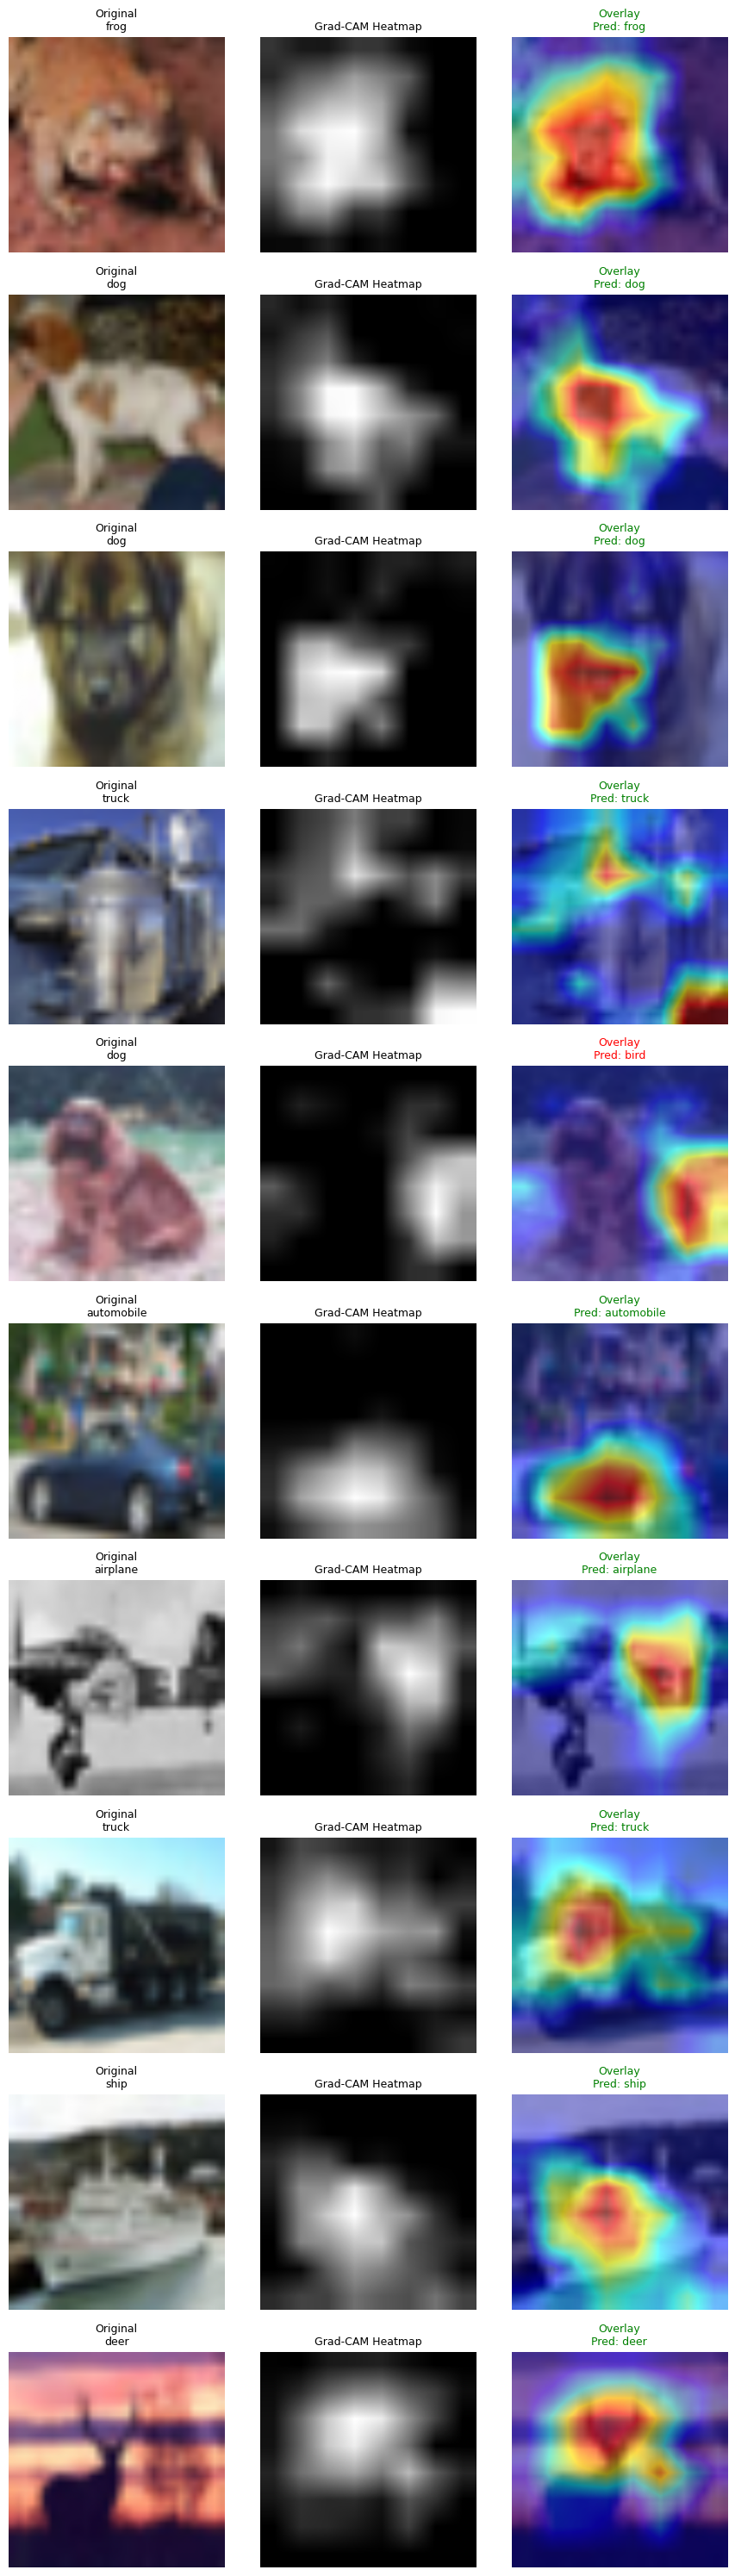

In [14]:
# --- Load model ---
trained_model = timm.create_model("resnet18.a1_in1k", num_classes=len(CLASSES))
state = torch.load(
    "kse_deep_learning_course/eoxk1gu0/checkpoints/cifar10_resnet18_baseline-epoch=19-val_acc=0.8467.ckpt",
    map_location="cpu",
    weights_only=False
)["state_dict"]
trained_model.load_state_dict({k.replace("model.", ""): v for k, v in state.items()})
trained_model.to(DEVICE)
trained_model.eval()

# --------------------------
# DATASET
# --------------------------
transform = T.Compose([
    T.Resize((227, 227)),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

testset = torchvision.datasets.CIFAR10(
    root='../../data',
    train=False,
    download=True,
    transform=transform
)

# pick multiple samples
indices = [5, 12, 33, 47, 101, 122, 153, 175, 196, 211]
tensors = torch.stack([testset[i][0] for i in indices]).to(DEVICE)
labels = [testset[i][1] for i in indices]

# original RGBs for visualization
original_imgs = [cv2.resize(np.array(testset.data[i]), (227, 227)) for i in indices]
rgb_imgs = [np.float32(img) / 255.0 for img in original_imgs]

# --------------------------
# GRAD-CAM
# --------------------------
target_layers = [trained_model.get_submodule("layer4")]

# Compute predictions
with torch.no_grad():
    preds = trained_model(tensors).argmax(dim=1).cpu().numpy()

# Generate Grad-CAMs for each image (predicted class)
targets = [ClassifierOutputTarget(int(p)) for p in preds]
with GradCAM(model=trained_model, target_layers=target_layers) as cam:
    grayscale_cams = cam(input_tensor=tensors, targets=targets)

# --------------------------
# VISUALIZATION
# --------------------------
n = len(indices)
rows, cols = n, 3  # original | heatmap | overlay
fig, axes = plt.subplots(rows, cols, figsize=(9, 3 * n))

for i in range(n):
    img = rgb_imgs[i]
    cam_map = grayscale_cams[i]
    cam_image = show_cam_on_image(img, cam_map, use_rgb=True)

    # normalize heatmap to uint8 for visualization
    cam_uint8 = np.uint8(255 * cam_map)
    cam_color = cv2.merge([cam_uint8, cam_uint8, cam_uint8])

    true_label = CLASSES[labels[i]]
    pred_label = CLASSES[preds[i]]

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Original\n{true_label}", fontsize=9)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(cam_color)
    axes[i, 1].set_title("Grad-CAM Heatmap", fontsize=9)
    axes[i, 1].axis("off")

    axes[i, 2].imshow(cam_image)
    axes[i, 2].set_title(
        f"Overlay\nPred: {pred_label}",
        fontsize=9,
        color="green" if true_label == pred_label else "red"
    )
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()


<a id='ResNet'></a>
# [ResNet](https://arxiv.org/abs/1512.03385)

## 🎯 Goal  
To understand the **ResNet (Residual Network)** architecture — one of the most influential CNN models that enabled the successful training of *very deep neural networks* by introducing **skip (residual) connections**.

---

## Motivation

Before ResNet, increasing CNN depth often led to **degradation problems** — deeper models performed *worse* due to vanishing gradients and optimization difficulties.

Even when overfitting was not the issue, deeper networks **failed to converge** properly.

ResNet solved this by introducing **residual learning**, allowing the network to learn residual mappings instead of direct transformations.

---

## Key Idea: Residual Learning

Instead of directly learning a mapping $H(x)$, ResNet learns a **residual function**:

$$
H(x) = F(x) + x
$$

where:
- $x$ — input to a layer (or block)  
- $F(x)$ — learned residual mapping (stack of conv–BN–ReLU layers)  
- $H(x)$ — desired underlying mapping  

Thus, each block outputs:

$$
y = F(x, \{W_i\}) + x
$$

The addition (identity skip) allows **gradients to flow directly** through the shortcut path, mitigating vanishing gradients.

---

## Residual Block Architecture

The core innovation of ResNet is the **residual block**, which introduces **skip connections** (also known as shortcut connections).  
Instead of learning a direct mapping, the network learns a residual function that is added to the input.

**Structure:**

`Input → Conv(3×3) → BN → ReLU → Conv(3×3) → BN → Add(Input) → ReLU`

If the dimensions of the input and output differ, a $1×1$ convolution is applied to the shortcut path to match the channel dimensions.

**Mathematical Formulation:**

$$
y = F(x, \{W_i\}) + x
$$

where:
- $x$ — input to the block  
- $F(x, \{W_i\})$ — residual mapping (learned transformation)  
- $y$ — output after addition and activation

This residual addition ensures that gradients can propagate directly through the identity connection, effectively mitigating vanishing gradients.

![](images/residual_block.png) <be>
    
*Taken from [Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385)*

---

## Deep Residual Networks

ResNet architectures come in multiple depths, each composed of stacked residual blocks.  
Deeper networks leverage **bottleneck structures** to balance computational efficiency and representational power.

| Model | Layers | Parameters | Top-1 Accuracy (ImageNet) |
|--------|---------|-------------|---------------------------|
| **ResNet-18** | 18 | 11.7M | ~69% |
| **ResNet-34** | 34 | 21.8M | ~73% |
| **ResNet-50** | 50 | 25.6M | ~76% |
| **ResNet-101** | 101 | 44.5M | ~78% |
| **ResNet-152** | 152 | 60.2M | ~78.5% |



<a id='EfficientNet'></a>
# [EfficientNet](https://arxiv.org/abs/1905.11946)

## 🎯 Goal  
EfficientNet introduced a **systematic scaling strategy** to optimize the trade-off between **accuracy** and **efficiency** (speed, memory, and FLOPs) by uniformly scaling **depth**, **width**, and **resolution** of CNNs.

---

## Motivation

Before EfficientNet, deeper and wider models (e.g., ResNet, DenseNet) were often designed through **manual scaling** — increasing either:
- **Depth** → add more layers  
- **Width** → add more channels  
- **Resolution** → feed higher-resolution inputs  

However, naive scaling often led to suboptimal trade-offs between accuracy and computational cost.

EfficientNet introduced a **compound scaling method**, enabling balanced scaling across all three dimensions.

---

## Compound Scaling Rule

Instead of arbitrarily scaling one dimension, EfficientNet introduces a **compound coefficient $\phi$**, which uniformly scales network width ($w$), depth ($d$), and resolution ($r$) using constants $\alpha$, $\beta$, and $\gamma$:

$$
\begin{aligned}
\text{depth: } d &= \alpha^{\phi} \\
\text{width: } w &= \beta^{\phi} \\
\text{resolution: } r &= \gamma^{\phi}
\end{aligned}
$$

subject to the constraint:

$$
\alpha \cdot \beta^2 \cdot \gamma^2 \approx 2
$$

This ensures that increasing $\phi$ by 1 approximately doubles the computational cost (FLOPs) while maintaining efficiency.

![](images/effnet_scaling_width.png) <be>
    
*Taken from [EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks](https://arxiv.org/abs/1905.11946)*

![](images/effnet_gradcams.png) <be>
    
*Taken from [EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks](https://arxiv.org/abs/1905.11946)*

---

## EfficientNet Architecture

EfficientNet is built upon a **baseline network (EfficientNet-B0)** optimized using **Neural Architecture Search (NAS)**.  
The resulting model uses:
- **MBConv blocks** (Mobile Inverted Bottleneck Convolutions) from MobileNetV2  
- **Squeeze-and-Excitation (SE)** modules for channel attention  
- **Swish (SiLU)** activation function  
- Compound scaling for larger variants: **B1–B7**

## EfficientNet Scaling Family

| Model | φ | Input Resolution | Depth | Width Multiplier | Top-1 Accuracy (ImageNet) | Params (M) |
|--------|--:|------------------|-------|------------------|----------------------------|-------------|
| **B0** | 0 | 224×224 | 1.0× | 1.0× | 77.1% | 5.3 |
| **B1** | 1 | 240×240 | 1.1× | 1.0× | 79.1% | 7.8 |
| **B2** | 2 | 260×260 | 1.2× | 1.1× | 80.1% | 9.2 |
| **B3** | 3 | 300×300 | 1.4× | 1.2× | 81.6% | 12 |
| **B4** | 4 | 380×380 | 1.8× | 1.4× | 83.0% | 19 |
| **B5** | 5 | 456×456 | 2.2× | 1.6× | 83.6% | 30 |
| **B6** | 6 | 528×528 | 2.6× | 1.8× | 84.0% | 43 |
| **B7** | 7 | 600×600 | 3.1× | 2.0× | 84.3% | 66 |

In [12]:
class CIFAR10DataModuleAugmentationsEffnetB0(CIFAR10DataModule):

    def setup(self, stage=None):
        train_tfms = A.Compose([
            A.Resize(224, 224),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.5, contrast_limit=0.5, p=0.5),
            A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5),
            A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
            ToTensorV2()
        ])

        val_tfms = A.Compose([
            A.Resize(224, 224),
            A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
            ToTensorV2()
        ])
        
        self.train_ds = CIFAR10AlbumentationsDataset(
            root=self.data_root, train=True, download=True, transform=train_tfms
        )
        self.val_ds = CIFAR10AlbumentationsDataset(
            root=self.data_root, train=False, download=True, transform=val_tfms
        )

N_EPOCHS = 20

datamodule = CIFAR10DataModuleAugmentationsEffnetB0(num_workers=12, batch_size=64)
datamodule.setup()
lit_model = LitCNN(
    model_class=timm.create_model,
    model_kwargs={
        "model_name": "tf_efficientnet_b0.in1k",
        "num_classes": len(CLASSES),
        "pretrained": True
    },
    initial_lr=1e-3,
    final_lr=1e-5,
    T_max=N_EPOCHS * len(datamodule.train_dataloader()),
)
wandb_logger = WandbLogger(
    project="kse_deep_learning_course", 
    name="cifar10_effnetb0"
)
checkpoint_cb = ModelCheckpoint(
    monitor="val_acc", mode="max",
    save_top_k=1, filename="cifar10_effnetb0-{epoch:02d}-{val_acc:.4f}"
)
lr_monitor = LearningRateMonitor(logging_interval="step")
trainer = pl.Trainer(
    max_epochs=N_EPOCHS,
    logger=wandb_logger,
    callbacks=[checkpoint_cb, lr_monitor],
    accelerator="auto",
    devices=1 if DEVICE == "cuda" else None,
    precision="16-mixed"
)

trainer.fit(lit_model, datamodule=datamodule)
wandb.finish()

/gpfs/helios/home/volodymyr1/src/kse_deep_learning/.venv/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /gpfs/helios/home/volodymyr1/src/kse_deep_learning/. ...
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/gpfs/helios/home/volodymyr1/src/kse_deep_learning/.venv/lib/python3.11/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | model     | EfficientNet       | 4.0 M  | train
1 | criterion | CrossEntropyLoss   | 0      | train
2 | train_acc | MulticlassAccuracy | 0      | train
3 | val_acc   | MulticlassAccuracy | 0      | train
---------------------------------------------------------
4.0 M     Trainable params
0         Non-trainable params
4.0 M     Total params
16.081    Total estimated model params size (MB)
340       Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_epochs=20` reached.


epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇██
lr-Adam,████████▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
train_acc,▁▄▅▅▆▆▆▇▇▇▇▇████████
train_loss_epoch,█▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁
train_loss_step,▇█▆▄▅▄▃▃▄▃▄▃▂▃▂▂▂▃▃▂▂▂▂▂▁▂▃▂▂▂▁▁▂▂▁▁▁▁▂▁
trainer/global_step,▁▁▁▁▂▂▂▃▃▃▄▄▄▄▄▄▄▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇██
val_acc,▁▃▃▄▅▅▅▅▆▆▇▇▇▇▇█████
val_loss,█▆▅▄▄▃▃▃▃▂▁▂▂▂▁▁▁▁▁▁
epoch,19
lr-Adam,1e-05
train_acc,0.98658


<a id='ConvNeXt'></a>
# [ConvNeXt](https://arxiv.org/abs/2201.03545)

![](images/convnext_intro.png) <be>
    
*Taken from [A ConvNet for the 2020s](https://arxiv.org/abs/2201.03545)*

## Goal  
ConvNeXt revisits and **modernizes the standard convolutional network design**, showing that with the right updates, CNNs can **match or even surpass Vision Transformers (ViTs)** in performance — while maintaining superior efficiency and inductive bias.

---

## Motivation

After the success of Vision Transformers (ViTs), the research community shifted heavily toward transformer-based architectures.  
However, ConvNeXt (Liu et al., 2022) demonstrated that **pure CNNs can remain competitive** when equipped with modern architectural and training strategies inspired by transformers.

---

## Design Philosophy

ConvNeXt is **based on ResNet**, but incorporates multiple **transformer-inspired design improvements**:

| Transformer-Inspired Feature | CNN Adaptation in ConvNeXt |
|-------------------------------|-----------------------------|
| Patchify input (ViT) | 4×4 stem convolution instead of 7×7 |
| Multi-head self-attention | Large-kernel depthwise convolutions |
| LayerNorm | Replaces BatchNorm in several locations |
| GELU activation | Replaces ReLU |
| Residual connections | Preserved (as in ResNet) |
| Simplified stage design | Uniform block structure |
| Global average pooling | Maintained for classification head |

![](images/convnext.png) <be>
    
*Taken from [A ConvNet for the 2020s](https://arxiv.org/abs/2201.03545)*

---

## Key Design Improvements

1. **Larger Kernels**  
   Replacing small 3×3 convolutions with **7×7 depthwise convolutions** increases the receptive field, allowing the model to capture more global context with fewer layers.

2. **Normalization Upgrade**  
   **LayerNorm** replaces **BatchNorm**, providing better stability in deep architectures and aligning CNNs with Transformer design practices.

3. **Activation Function**  
   Using **GELU** (Gaussian Error Linear Unit) instead of ReLU results in smoother gradient flow and improved convergence.

4. **Inverted Bottlenecks**  
   Following MobileNetV2’s principle, the ConvNeXt block expands the number of channels before reducing them again, improving representational efficiency.

5. **Simplified Downsampling**  
   ConvNeXt replaces traditional pooling layers with **2×2 stride convolutions**, maintaining learnability while reducing artifacts from pooling operations.

## Model Scaling

ConvNeXt follows a **hierarchical stage design**, similar to ResNet, with four progressively deeper stages.  
Each stage reduces spatial resolution while increasing the number of feature channels.

| Model | Input | Params (M) | FLOPs (B) | Top-1 Accuracy (ImageNet) |
|--------|--------|-------------|------------|----------------------------|
| **ConvNeXt-Tiny** | 224×224 | 29 | 4.5 | 82.1% |
| **ConvNeXt-Small** | 224×224 | 50 | 8.7 | 83.1% |
| **ConvNeXt-Base** | 224×224 | 89 | 15.4 | 83.8% |
| **ConvNeXt-Large** | 224×224 | 198 | 34.4 | 84.3% |
| **ConvNeXt-XL** | 224×224 | 350 | 60.9 | 84.6% |

The scaling strategy maintains balance between model size and performance, similar to EfficientNet’s compound scaling but applied within a purely convolutional architecture.



In [13]:
class CIFAR10DataModuleAugmentationsConvNextTiny(CIFAR10DataModule):

    def setup(self, stage=None):
        train_tfms = A.Compose([
            A.Resize(224, 224),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.5, contrast_limit=0.5, p=0.5),
            A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5),
            A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
            ToTensorV2()
        ])

        val_tfms = A.Compose([
            A.Resize(224, 224),
            A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
            ToTensorV2()
        ])
        
        self.train_ds = CIFAR10AlbumentationsDataset(
            root=self.data_root, train=True, download=True, transform=train_tfms
        )
        self.val_ds = CIFAR10AlbumentationsDataset(
            root=self.data_root, train=False, download=True, transform=val_tfms
        )

N_EPOCHS = 20

datamodule = CIFAR10DataModuleAugmentationsConvNextTiny(num_workers=12, batch_size=64)
datamodule.setup()
lit_model = LitCNN(
    model_class=timm.create_model,
    model_kwargs={
        "model_name": "convnext_tiny.fb_in1k",
        "num_classes": len(CLASSES),
        "pretrained": True
    },
    initial_lr=1e-3,
    final_lr=1e-5,
    T_max=N_EPOCHS * len(datamodule.train_dataloader()),
)
wandb_logger = WandbLogger(
    project="kse_deep_learning_course", 
    name="cifar10_convnexttiny"
)
checkpoint_cb = ModelCheckpoint(
    monitor="val_acc", mode="max",
    save_top_k=1, filename="cifar10_convnexttiny-{epoch:02d}-{val_acc:.4f}"
)
lr_monitor = LearningRateMonitor(logging_interval="step")
trainer = pl.Trainer(
    max_epochs=N_EPOCHS,
    logger=wandb_logger,
    callbacks=[checkpoint_cb, lr_monitor],
    accelerator="auto",
    devices=1 if DEVICE == "cuda" else None,
    precision="16-mixed"
)

trainer.fit(lit_model, datamodule=datamodule)
wandb.finish()

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

/gpfs/helios/home/volodymyr1/src/kse_deep_learning/.venv/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /gpfs/helios/home/volodymyr1/src/kse_deep_learning/. ...
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/gpfs/helios/home/volodymyr1/src/kse_deep_learning/.venv/lib/python3.11/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | model     | ConvNeXt           | 27.8 M | train
1 | criterion | CrossEntropyLoss   | 0      | train
2 | train_acc | MulticlassAccuracy | 0      | train
3 | val_acc   | MulticlassAccuracy | 0      | train
---------------------------------------------------------
27.8 M    Trainable params
0         Non-trainable params
27.8 M    Total params
111.311   Total estimated model params size (MB)
252       Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_epochs=20` reached.


epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▇▇█████
lr-Adam,█████▇▇▇▇▇▆▆▆▆▆▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
train_acc,▁▄▅▅▆▆▆▇▇▇▇▇████████
train_loss_epoch,█▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁
train_loss_step,█▅▄▆▄▄▅▄▂▃▄▃▄▂▃▃▂▂▂▂▁▂▃▁▁▁▁▂▂▁▂▂▂▁▁▂▁▁▁▁
trainer/global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇████
val_acc,▃▁▃▄▆▅▅▇▆▇▇▇▇▇▇█████
val_loss,▆█▅▅▃▃▂▂▂▂▂▂▂▁▂▂▁▁▁▁
epoch,19
lr-Adam,1e-05
train_acc,0.99074


# Results

In [19]:
cnn_results = pd.read_csv(
    "cnn_exps.csv"
)
cnn_results.loc[len(cnn_results)] = {
    "Name" : "cifar10_alexnet_withBN_augmentations_20epochs + TTA",
    "train_acc (Max)": None,
    "val_acc (Max)": f1_tta
}

/tmp/ipykernel_3126616/3614096943.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cnn_results.loc[len(cnn_results)] = {


In [23]:
cnn_results.sort_values("val_acc (Max)", ascending=False)

,Name,train_acc (Max),val_acc (Max)
0,cifar10_convnexttiny,0.99074,0.970300
1,cifar10_effnetb0,0.98658,0.964200
2,cifar10_resnet18_pretrained,0.97744,0.951000
3,cifar10_resnet18_baseline,0.88488,0.846700
7,cifar10_alexnet_withBN_augmentations_20epochs + TTA,NaN,0.775699
4,cifar10_alexnet_withBN,0.78060,0.771600
5,cifar10_alexnet_withBN_augmentations_20epochs,0.73384,0.761700
6,cifar10_alexnet_withBN_augmentations,0.50948,0.549100


## Plots without Pretrain

![](images/wb_without_pretrain.png) <be>

## Plots with Pretrain

![](images/wb_with_pretrain.png) <be>

<a id='Cats_and_Dogs'></a>
# Example with Cats and Dogs++

In [15]:
CLASSES = ["Cat", "Dog", "Moris", "Motya", "Biatrix"]
N_CLASSES = len(CLASSES)

In [16]:
class MultilabelImageDataset(torch.utils.data.Dataset):
    def __init__(self, df, img_dir, ext=".jpg", transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        self.ext = ext

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_id"] + self.ext)
        image = np.array(Image.open(img_path).convert("RGB"))
        labels = torch.tensor(row[CLASSES].values.astype(np.float32))

        if self.transform:
            image = self.transform(image=image)["image"]

        return image, labels

In [17]:
class LitCNNMultiLabel(pl.LightningModule):
    def __init__(
        self, 
        model_class,
        model_kwargs,
        initial_lr=1e-3, 
        final_lr=1e-5, 
        T_max=10,
    ):
        super().__init__()
        self.save_hyperparameters()
        self.model = model_class(**model_kwargs)
        self.criterion = nn.CrossEntropyLoss()
        self.train_f1 = torchmetrics.F1Score(task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES), average="macro")
        self.val_f1 = torchmetrics.F1Score(task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES), average="macro")

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = (torch.sigmoid(logits) > 0.5).float()
        self.train_f1.update(preds, y.int())
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        self.log("train_f1", self.train_f1.compute(), prog_bar=True)
        self.train_f1.reset()

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = logits.argmax(dim=-1)
        self.val_acc.update(preds, y)
        self.log("val_loss", loss, on_epoch=True, prog_bar=True)

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = (torch.sigmoid(logits) > 0.5).float()
        self.val_f1.update(preds, y.int())
        self.log("val_loss", loss, on_epoch=True, prog_bar=True)

    def on_validation_epoch_end(self):
        self.log("val_f1", self.val_f1.compute(), prog_bar=True)
        self.val_f1.reset()

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            self.parameters(), 
            lr=self.hparams.initial_lr
        )
        scheduler = {
            "scheduler": torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, 
                T_max=self.hparams.T_max,
                eta_min=self.hparams.final_lr
            ),
            "interval": "step"
        }
        return (
            [optimizer],
            [scheduler]
        )

class KaggleDataModule(pl.LightningDataModule):
    def __init__(self, df, img_dir, batch_size=32, num_workers=4, fold=0):
        super().__init__()
        self.df = df
        self.img_dir = img_dir
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.fold = fold

    def setup(self, stage=None):
        train_df = self.df[self.df["fold"] != self.fold].reset_index(drop=True)
        val_df = self.df[self.df["fold"] == self.fold].reset_index(drop=True)

        train_tfms = A.Compose([
            A.Resize(224, 224),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=15, p=0.5),
            A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            ToTensorV2()
        ])

        val_tfms = A.Compose([
            A.Resize(224, 224),
            A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            ToTensorV2()
        ])

        self.train_ds = MultilabelImageDataset(train_df, self.img_dir, transform=train_tfms)
        self.val_ds = MultilabelImageDataset(val_df, self.img_dir, transform=val_tfms)

    def train_dataloader(self):
        return torch.utils.data.DataLoader(
            self.train_ds, batch_size=self.batch_size, 
            shuffle=True, pin_memory=torch.cuda.is_available(),
            num_workers=self.num_workers
        )

    def val_dataloader(self):
        return torch.utils.data.DataLoader(
            self.val_ds, batch_size=self.batch_size, 
            shuffle=False, pin_memory=torch.cuda.is_available(),
            num_workers=self.num_workers
        )

In [18]:
def create_folds(input_df):
    mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=95431)
    input_df["fold"] = -1
    for fold, (_, val_idx) in enumerate(mskf.split(input_df, input_df[CLASSES].values)):
        input_df.loc[val_idx, "fold"] = fold
    return input_df

In [19]:
full_df = pd.read_csv(
    "../../data/cats_and_dog_plus_plus/cats-and-dogs-plus-plus/train.csv"
)
full_df = create_folds(full_df)
full_df.head()

,image_id,Cat,Dog,Moris,Motya,Biatrix,fold
0,7e17a6e589f9c891857b32bbb3652d19b7d5a215,0,0,0,0,0,2
1,7ad97bd6c7ef98373f43f2bbd1e41b2bbff4687e,1,0,0,0,0,3
2,d29be872d012d8766c5942847d1d721788fd9511,0,1,0,0,0,2
3,bec7727bfc721629997d782ec020ee555990128f,0,1,0,0,0,0
4,58bb7362153d945f48721004bc8fb2ee73a855b0,0,1,0,0,0,0


In [20]:
N_EPOCHS = 20

datamodule = KaggleDataModule(
    df=full_df, 
    img_dir="../../data/cats_and_dog_plus_plus/cats-and-dogs-plus-plus/train/", 
    num_workers=12, 
    batch_size=64
)
datamodule.setup()
lit_model = LitCNNMultiLabel(
    model_class=timm.create_model,
    model_kwargs={
        "model_name": "tf_efficientnet_b0.in1k",
        "num_classes": len(CLASSES),
        "pretrained": True
    },
    initial_lr=1e-3,
    final_lr=1e-5,
    T_max=N_EPOCHS * len(datamodule.train_dataloader()),
)
wandb_logger = WandbLogger(
    project="cats_and_dogs_plus_plus", 
    name="cifar10_effnetb0"
)
checkpoint_cb = ModelCheckpoint(
    monitor="val_f1", mode="max",
    save_top_k=1, filename="cifar10_effnetb0-{epoch:02d}-{val_f1:.4f}"
)
lr_monitor = LearningRateMonitor(logging_interval="step")
trainer = pl.Trainer(
    max_epochs=N_EPOCHS,
    logger=wandb_logger,
    callbacks=[checkpoint_cb, lr_monitor],
    accelerator="auto",
    devices=1 if DEVICE == "cuda" else None,
    precision="16-mixed"
)

trainer.fit(lit_model, datamodule=datamodule)
wandb.finish()

/gpfs/helios/home/volodymyr1/src/kse_deep_learning/.venv/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/gpfs/helios/home/volodymyr1/src/kse_deep_learning/.venv/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /gpfs/helios/home/volodymyr1/src/kse_deep_learning/. ...
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


/gpfs/helios/home/volodymyr1/src/kse_deep_learning/.venv/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/gpfs/helios/home/volodymyr1/src/kse_deep_learning/.venv/lib/python3.11/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name      | Type              | Params | Mode 
--------------------------------------------------------
0 | model     | EfficientNet      | 4.0 M  | train
1 | criterion | CrossEntropyLoss  | 0      | train
2 | train_f1  | MultilabelF1Score | 0      | train
3 | val_f1    | MultilabelF1Score | 0      | train
--------------------------------------------------------
4.0 M     Trainable params
0      

Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_epochs=20` reached.


epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇████
lr-Adam,████████▇▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁
train_f1,▁▆▆▅▇▇▇▆▅▆▇▇▇███████
train_loss_epoch,█▃▂▃▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁
train_loss_step,█▂▁▂▂▁▁▁▂▁▂▁▁▁▂▁▁▁▂▁▁▁▂▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
val_f1,▆▁▅▅▄█▅▃▄▅▅▆▆▆▆▆▇▆▆▇
val_loss,▇▃█▄▅▂▄▂▃▂▁▂▁▁▁▁▁▁▁▁
epoch,19
lr-Adam,1e-05
train_f1,0.36464


In [22]:
# Load best checkpoint
best_model = LitCNN.load_from_checkpoint(
    "cats_and_dogs_plus_plus/n8w5iuji/checkpoints/cifar10_effnetb0-epoch=05-val_f1=0.3678.ckpt",
    model_class=timm.create_model,
    model_kwargs={
        "model_name": "tf_efficientnet_b0.in1k",
        "num_classes": len(CLASSES),
        "pretrained": True
    },
)
best_model.eval().to(DEVICE)


# Collect predictions on validation set
all_preds, all_targets = [], []
for x, y in datamodule.val_dataloader():
    x = x.to(DEVICE)
    with torch.no_grad():
        logits = best_model(x)
        preds = (torch.sigmoid(logits) > 0.5).cpu().numpy()
    all_preds.append(preds)
    all_targets.append(y.numpy())

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

# Compute metrics
f1_macro = f1_score(all_targets, all_preds, average="macro")
f1_per_class = f1_score(all_targets, all_preds, average=None)

print("Macro F1:", f1_macro)
for cls, f1_val in zip(CLASSES, f1_per_class):
    print(f"{cls}: {f1_val:.4f}")

Macro F1: 0.36770036608283463
Cat: 0.7772
Dog: 0.7464
Moris: 0.1760
Motya: 0.0357
Biatrix: 0.1032


![](images/lb_results.png) <be>

In [23]:
# --- Reference to validation dataset ---
val_ds = datamodule.val_ds

✅ Selected 5 representative samples (one per class)


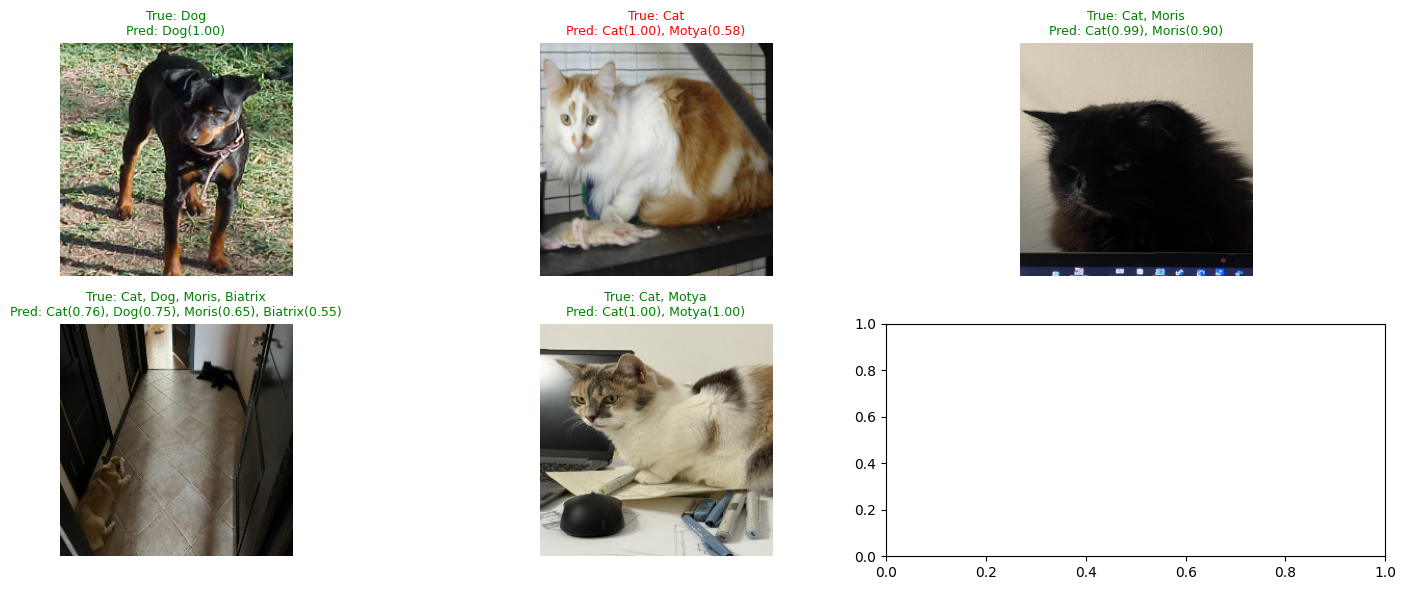

In [24]:
# --- Select one sample per class ---
selected_indices = []
seen_classes = set()


it_idxs = list(range(len(val_ds)))
np.random.shuffle(it_idxs)
for idx in it_idxs:
    _, labels = val_ds[idx]
    active_classes = np.where(labels.numpy() == 1)[0]
    for cls_idx in active_classes:
        if cls_idx not in seen_classes:
            selected_indices.append(idx)
            seen_classes.add(cls_idx)
    if len(seen_classes) == len(CLASSES):
        break

print(f"✅ Selected {len(selected_indices)} representative samples (one per class)")

# --- Prepare batch ---
images = torch.stack([val_ds[i][0] for i in selected_indices]).to(DEVICE)
labels = torch.stack([val_ds[i][1] for i in selected_indices])

# --- Make predictions ---
with torch.no_grad():
    logits = best_model(images)
    probs = torch.sigmoid(logits).cpu().numpy()
    preds = (probs > 0.5).astype(int)

# --- Helper: denormalize for visualization ---
def denormalize(img_tensor):
    img = img_tensor.clone()
    img = img * 0.5 + 0.5  # reverse normalization
    return img.clamp(0, 1)

# --- Visualization ---
fig, axes = plt.subplots(2, len(selected_indices)//2 + len(selected_indices)%2, figsize=(15, 6))
axes = axes.flatten()

for i, idx in enumerate(selected_indices):
    img = denormalize(images[i].cpu()).permute(1, 2, 0).numpy()
    true_classes = [CLASSES[j] for j, val in enumerate(labels[i]) if val == 1]
    pred_classes = [CLASSES[j] for j, val in enumerate(preds[i]) if val == 1]
    confs = [f"{CLASSES[j]}({probs[i][j]:.2f})" for j in range(len(CLASSES)) if preds[i][j] == 1]

    axes[i].imshow(img)
    axes[i].axis("off")

    color = "green" if set(true_classes) == set(pred_classes) else "red"
    axes[i].set_title(
        f"True: {', '.join(true_classes)}\nPred: {', '.join(confs)}",
        fontsize=9,
        color=color
    )

plt.tight_layout()
plt.show()

In [25]:
# --- Albumentations transforms (same as val) ---
test_tfms = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

# --- Load test dataframe ---
test_df = pd.read_csv("../../data/cats_and_dog_plus_plus/cats-and-dogs-plus-plus/sample_submission.csv")

# --- Create test dataset using your dataset class ---
test_ds = MultilabelImageDataset(
    df=test_df,
    img_dir="../../data/cats_and_dog_plus_plus/cats-and-dogs-plus-plus/test/",        # Folder with test images
    transform=test_tfms
)

test_loader = torch.utils.data.DataLoader(
    test_ds,
    batch_size=64,
    shuffle=False,
    num_workers=8,
    pin_memory=True
)

# --- Perform predictions ---
all_probs = []
image_ids = test_df["image_id"].values

with torch.no_grad():
    for batch_imgs, _ in tqdm(test_loader, desc="Predicting on test"):
        batch_imgs = batch_imgs.to(DEVICE)
        logits = best_model(batch_imgs)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)

# --- Concatenate all predictions ---
all_probs = np.concatenate(all_probs, axis=0)

# --- Threshold predictions ---
preds = (all_probs > 0.5).astype(int)

Predicting on test: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 288/288 [00:20<00:00, 14.06it/s]


In [26]:
test_df[CLASSES] = preds

test_df.head()

,image_id,Cat,Dog,Moris,Motya,Biatrix
0,7e9de2837ab0f90176c0e6c2e30c2c136f1f00d9,0,1,0,0,0
1,11e8173dd91e7a00f8bdbc64067d6f167c9bbed2,1,0,0,1,0
2,415c62c8d85c0a13300ba25f4a5e6582eb468c31,1,1,0,0,1
3,4fbdedc390d83a9b264dc8e0ea803c4307a7f891,1,0,0,1,0
4,fb43e55f67815f61d3f298b8cc1947f278676ee5,0,1,0,0,0


In [27]:
test_df.to_csv(
    "../../data/cats_and_dog_plus_plus/cats-and-dogs-plus-plus/effnetb0_baseline.csv",
    index=False
)